# NIH CXR8 Multi-Label Chest X-Ray Classification
## SimMIM-Pretrained SwinTransformerV2 with View-Position Conditioning
**Authors:** Nicholas J. Calabro · Group 5  
**Dataset:** NIH ChestX-ray8 (Wang et al. 2017) - 112,120 frontal-view X-rays, 15 pathology labels  
**Backbone:** SwinTransformerV2-Small pre-trained with SimMIM self-supervised learning  
**Head:** Per-class cross-attention MLP conditioned on radiographic view position (PA / AP)

---
### Notebook Structure
1. Environment Setup & Imports  
2. Configuration (all hyper-parameters in one place)  
3. Data Preprocessing Pipeline  
4. Dataset & DataLoader  
5. Model Architecture  
6. Training Process  
7. Final Evaluation & Performance Metrics  
8. Visualisations

## 1. Environment Setup & Imports

In [2]:
# Dependency Installation
# Run this cell once before any other cell.
# Restart the kernel after installation completes.
import subprocess, sys

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])

# Core scientific stack
pip("numpy", "pandas", "scipy")
pip("timm")

# PyTorch — installs CUDA 12.1 wheels; swap index URL for CPU-only or different CUDA version:
#   CPU-only:  https://download.pytorch.org/whl/cpu
#   CUDA 11.8: https://download.pytorch.org/whl/cu118
pip("torch", "torchvision",
    "--index-url", "https://download.pytorch.org/whl/cu121")

# Image augmentation
pip("albumentations")
pip("opencv-python-headless")   # headless avoids GUI deps inside notebooks
pip("Pillow")

# Scikit-learn (metrics, splitting, binarisation)
pip("scikit-learn")

# Progress bars
pip("tqdm")

# Visualisation
pip("matplotlib", "seaborn")

# Verify critical imports and print versions
import torch, torchvision, albumentations, cv2, sklearn, PIL, matplotlib, seaborn
print(f"torch            {torch.__version__}   (CUDA available: {torch.cuda.is_available()})")
print(f"torchvision      {torchvision.__version__}")
print(f"albumentations   {albumentations.__version__}")
print(f"opencv           {cv2.__version__}")
print(f"scikit-learn     {sklearn.__version__}")
print(f"Pillow           {PIL.__version__}")
print(f"matplotlib       {matplotlib.__version__}")
print(f"seaborn          {seaborn.__version__}")
print("\nAll dependencies installed. Restart the kernel now before proceeding.")

torch            2.10.0+cpu   (CUDA available: False)
torchvision      0.25.0+cpu
albumentations   2.0.8
opencv           4.13.0
scikit-learn     1.7.2
Pillow           12.0.0
matplotlib       3.10.6
seaborn          0.13.2

All dependencies installed. Restart the kernel now before proceeding.


In [1]:
# Core
import os, glob, math, time, datetime, csv, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
from pathlib import Path

# ML / DL
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn
import torchvision

# Image augmentation
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Scikit-learn
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, roc_curve,
    multilabel_confusion_matrix, classification_report
)

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

# Microsoft Swin Transformer V2 implementation
# Required dependency;
# github.com/microsoft/Swin-Transformer/blob/main/models/swin_transformer_v2.py
from swin_transformer_v2 import SwinTransformerV2


# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU [{i}]:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cpu
CUDA available: False


## 2. Configuration
All hyper-parameters are declared here so the notebook is easy to re-run with
different settings without hunting through code cells.

In [2]:
# Paths
METADATA_CSV_PATH = "../chest_xray_dataset/CXR8/Data_Entry_2017_v2020.csv"
IMAGE_ROOT        = "../chest_xray_dataset/CXR8/images_preprocessed"
SSL_CKPT          = "../chest_xray_dataset/swinv2_small_1k_500k.pth"
MODEL_OUTPUT_FILE = "swin_cxr8_best.pth"
LOG_OUTPUT_FILE   = "training_log.csv"

# Image / model
IMAGE_SIZE  = 384
NUM_EPOCHS  = 35
PATIENCE    = 8

# Learning rates
BASE_LR            = 7e-5
HEAD_LR_MULTIPLIER = 6       # Head has no SSL pretraining; boost its LR
LR_LAYER_DECAY     = 0.8     # Deeper layers get lower LR (layer-wise decay)
WEIGHT_DECAY       = 1e-2
ETA_MIN_RATIO      = 0.09    # Cosine floor relative to each group's base_lr

# Asymmetric Loss
GAMMA_POS       = 0.0   # No down-weighting for positives
GAMMA_NEG       = 4.0   # Strong down-weighting for easy negatives
ASYMMETRIC_CLIP = 0.05  # Clip negative probability shift
LABEL_SMOOTH    = 0.05

# Regularisation
FEATURE_DROPOUT    = 0.2
CLASSIFIER_DROPOUT = 0.1
EMA_DECAY          = 0.9995  # Exponential Moving Average of weights

# View conditioning
VIEW_POSITION_SCALE = 0.2

# Sampler
SAMPLER_POWER = 0.17   # Mild over-sampling of rare classes

# Warmup schedule
WARMUP_EPOCHS       = 3
WARMUP_START_FACTOR = 0.3
WARMUP_END_FACTOR   = 1.0

# Progressive backbone unfreezing
# epoch  unfreeze all stages with index >= value
UNFREEZE_SCHEDULE = {2: 3, 4: 2, 6: 1, 8: 0}
UNFREEZE_WARMUP_EPOCHS  = 3
UNFREEZE_WARMUP_FACTOR  = 0.1
UNFREEZE_BUMP_FACTOR    = 1.6

# DataLoader Parameters
BATCH_SIZE_TRAIN  = 16
BATCH_SIZE_VAL    = 16
LOADER_WORKERS_TRAIN = 10
LOADER_WORKERS_VAL   = 2
PERSISTENT_WORKERS   = True
PREFETCH_FACTOR      = 2
CHECKPOINT_INTERVAL  = 5
HARDWARE_PITY        = 0    # Sleep seconds after train epoch (set >0 for hot GPUs)

# Evaluation
MIN_VAL_POSITIVES = 50   # Min positives needed for reliable AUC estimate

# Class names
ALL_CLASSES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Effusion",    "Emphysema",    "Fibrosis",      "Hernia",
    "Infiltration","Mass",         "No Finding",    "Nodule",
    "Pleural_Thickening", "Pneumonia", "Pneumothorax",
]
NUM_CLASSES    = len(ALL_CLASSES)
NO_FINDING_COL = ALL_CLASSES.index("No Finding")

# Expected missing keys from SSL checkpoint (positional encodings are recomputed)
EXPECTED_MISSING = {"relative_coords_table", "relative_position_index", "attn_mask"}

print(f"Training for up to {NUM_EPOCHS} epochs  |  {NUM_CLASSES} output classes")
print("Classes:", ALL_CLASSES)

Training for up to 35 epochs  |  15 output classes
Classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


## 3. Data Preprocessing Pipeline
The NIH CXR8 images are greyscale PNGs stored as pseudo-RGB.  
The pipeline applies the following steps in order:

| Step | Train | Validation |
|------|-------|-----------|
| Resize to 384×384 | ✓ | ✓ |
| CLAHE (local contrast enhancement) | ✓ | ✓ |
| Dataset normalisation (CXR8 mean/std) | ✓ | ✓ |
| Horizontal flip (p=0.5) | ✓ | - |
| Rotation ±2.8° (p=0.5) | ✓ | - |
| Elastic deformation | ✓ | - |
| Grid distortion | ✓ | - |
| Colour jitter (brightness/contrast) | ✓ | - |
| Coarse dropout (occlusion simulation) | ✓ | - |
| Per-image standardisation | ✓ | ✓ |


In [3]:
# Normalisation statistics
# Computed from the full CXR8 training split
NIH_CXR8_MEAN = [0.5249, 0.5249, 0.5249]
NIH_CXR8_STD  = [0.2622, 0.2622, 0.2622]

# Augmentation constants
CLAHE_CLIP_LIMIT   = 1.5
CLAHE_TILE_GRID    = 4
ELASTIC_ALPHA      = 1.0
ELASTIC_SIGMA      = 10.0
HORIZONTAL_FLIP_P  = 0.5
ROTATION_DEGREES   = 2.8
ROTATION_P         = 0.5
JITTER_P           = 0.5
JITTER_BRIGHTNESS  = 0.08
JITTER_CONTRAST    = 0.08


class PerImageStandardize:
    """Zero-mean, unit-variance normalisation per image.
    Removes global brightness variation that differs between PA and AP views.
    """
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean()
        std  = x.std()
        return (x - mean) / (std + 1e-6)


def make_train_tf(size: int) -> A.Compose:
    """Heavy augmentation pipeline for the training split."""
    return A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=HORIZONTAL_FLIP_P),
        A.Rotate(limit=ROTATION_DEGREES, p=ROTATION_P,
                 interpolation=cv2.INTER_LINEAR),
        A.CLAHE(clip_limit=CLAHE_CLIP_LIMIT,
                tile_grid_size=(CLAHE_TILE_GRID, CLAHE_TILE_GRID), p=1.0),
        A.ElasticTransform(alpha=ELASTIC_ALPHA, sigma=ELASTIC_SIGMA,
                           interpolation=cv2.INTER_LINEAR, fill=0, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.3),
        A.ColorJitter(brightness=JITTER_BRIGHTNESS,
                      contrast=JITTER_CONTRAST, p=JITTER_P),
        A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2),
        ToTensorV2(),
    ])


def make_val_tf(size: int) -> A.Compose:
    """Deterministic pipeline for validation / test."""
    return A.Compose([
        A.Resize(size, size),
        A.CLAHE(clip_limit=CLAHE_CLIP_LIMIT,
                tile_grid_size=(CLAHE_TILE_GRID, CLAHE_TILE_GRID), p=1.0),
        ToTensorV2(),
    ])


print("Transforms defined.")

Transforms defined.


## 4. Dataset & DataLoader
### 4.1 Metadata Loading and Patient-Level Split

The CXR8 metadata contains one row per image with columns for labels, view position
(PA - posterior-anterior, or AP - anterior-posterior), and patient ID.

**Patient-level splitting** is critical: a naive random split leaks information because
many patients have multiple images. We stratify at the patient level by label combination
so class distributions are balanced across train and validation sets.

In [13]:
def load_metadata(csv_path: str) -> pd.DataFrame:
    """Load CXR8 metadata, encode view position, and parse label strings."""
    df = pd.read_csv(csv_path)
    df = df[["Image Index", "Finding Labels", "View Position", "Patient ID"]].copy()
    # Keep only standard frontal views
    df = df[df["View Position"].isin(["PA", "AP"])].reset_index(drop=True)
    df["view_id"] = df["View Position"].map({"PA": 0, "AP": 1}).astype(int)
    df["labels"]  = df["Finding Labels"].str.split("|")
    return df


def patient_stratified_split(df: pd.DataFrame,
                              label_matrix: np.ndarray,
                              test_size: float = 0.15,
                              random_state: int = 42):
    """Split image indices at the *patient* level to prevent data leakage.

    Strategy
    --------
    1. Aggregate each patient's label flags via OR across their images.
    2. Convert the multi-hot vector to a string 'combo key'.
    3. Rare combos (< 2 patients) are collapsed to a single '__other__' stratum.
    4. Stratified shuffle split on the combo keys.
    """
    patient_ids = df["Patient ID"].unique()
    pid_to_idx  = {pid: i for i, pid in enumerate(patient_ids)}

    # Patient-level multi-hot matrix (OR over images)
    pat_lbl = np.zeros((len(patient_ids), label_matrix.shape[1]), dtype=int)
    for img_i, row in df.iterrows():
        p = pid_to_idx[row["Patient ID"]]
        pat_lbl[p] |= label_matrix[img_i]

    # Stratification key
    combos  = ["_".join(map(str, r)) for r in pat_lbl]
    counts  = Counter(combos)
    strat   = [c if counts[c] >= 2 else "__other__" for c in combos]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size,
                                 random_state=random_state)
    tr_pi, val_pi = next(sss.split(patient_ids, strat))

    train_pats = set(patient_ids[tr_pi])
    val_pats   = set(patient_ids[val_pi])

    train_idx = df[df["Patient ID"].isin(train_pats)].index.to_numpy()
    val_idx   = df[df["Patient ID"].isin(val_pats)].index.to_numpy()

    # Diagnostics
    for split, idx in [("train", train_idx), ("val", val_idx)]:
        n_hernia = label_matrix[idx, ALL_CLASSES.index("Hernia")].sum()
        print(f"  {split:5s}: {len(idx):6d} images | Hernia positives: {n_hernia}")

    return train_idx, val_idx


print("Metadata helpers defined.")

Metadata helpers defined.


### 4.2 Dataset Class (CXR8Dataset)
Returns `(image_tensor, label_tensor, view_id)` for each sample.  
The view ID (0 = PA, 1 = AP) is passed to the model's view-conditioning MLP.

In [8]:
def worker_init_fn(worker_id: int):
    """Prevent OpenCV from spawning extra threads inside DataLoader workers."""
    cv2.setNumThreads(0)


def tta_predict(model: nn.Module,
                imgs: torch.Tensor,
                views: torch.Tensor) -> torch.Tensor:
    """Test-Time Augmentation: average predictions over original + h-flip."""
    p1 = torch.sigmoid(model(imgs, views))
    p2 = torch.sigmoid(model(imgs.flip(-1), views))
    return (p1 + p2) / 2.0


class CXR8Dataset(Dataset):
    """
    Parameters
    ----------
    df          : full metadata DataFrame (already filtered to found images)
    labels      : multi-hot numpy array, shape (N, NUM_CLASSES)
    idx_array   : indices into df / labels for this split
    transform   : Albumentations Compose pipeline
    lookup      : dict mapping filename -> full path
    """
    def __init__(self, df, labels, idx_array, transform, lookup):
        self.df        = df.iloc[idx_array].reset_index(drop=True)
        self.labels    = labels[idx_array]
        self.transform = transform
        self.lookup    = lookup
        self._pis      = PerImageStandardize()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        fname = self.df.loc[i, "Image Index"]
        img   = np.array(Image.open(self.lookup[fname]).convert("RGB"))
        img   = self.transform(image=img)["image"]     # (C, H, W) float32
        img   = self._pis(img)                          # BUG FIX: result now assigned
        lbl   = torch.tensor(self.labels[i], dtype=torch.float32)
        view  = torch.tensor(self.df.loc[i, "view_id"], dtype=torch.long)
        return img, lbl, view


print("CXR8Dataset and helpers defined.")

CXR8Dataset and helpers defined.


### 4.3 Class Distribution Analysis
Understanding label frequency is essential because CXR8 is severely imbalanced.
`No Finding` accounts for ~53 % of images; `Hernia` < 0.2 %.

In [9]:
def plot_class_distribution(label_matrix: np.ndarray, title: str = "Class Distribution"):
    counts = label_matrix.sum(axis=0)
    df_plot = pd.DataFrame({"Class": ALL_CLASSES, "Count": counts})
    df_plot = df_plot.sort_values("Count", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(df_plot["Class"], df_plot["Count"],
                   color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(ALL_CLASSES))))
    ax.set_xlabel("Number of Positive Labels", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    for bar, cnt in zip(bars, df_plot["Count"]):
        ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                f"{int(cnt):,}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

# --- Run after loading data ---
# df = load_metadata(METADATA_CSV_PATH)
# all_png   = glob.glob(os.path.join(IMAGE_ROOT, "**", "*.png"), recursive=True)
# path_lookup = {os.path.basename(p): p for p in all_png}
# mlb = MultiLabelBinarizer(classes=ALL_CLASSES)
# label_matrix = mlb.fit_transform(df["labels"])
# mask = df["Image Index"].isin(path_lookup)
# df   = df[mask].reset_index(drop=True)
# label_matrix = label_matrix[mask.values]
# plot_class_distribution(label_matrix, "CXR8 Full Dataset - Label Counts")
print("plot_class_distribution() defined.")

plot_class_distribution() defined.


### 4.4 Weighted Random Sampler
Because the dataset is multi-label with severe class imbalance, a
`WeightedRandomSampler` is used. Sample weight = sum of inverse class-frequency weights
across a sample's positive labels, raised to `SAMPLER_POWER` to soften the effect.

In [10]:
def build_sampler(label_matrix_train: np.ndarray,
                  power: float = SAMPLER_POWER) -> WeightedRandomSampler:
    """Oversample rare classes by assigning higher weights to their images."""
    class_counts  = label_matrix_train.sum(axis=0)
    class_weights = 1.0 / (class_counts + 1e-6) ** power
    sample_weights = (label_matrix_train * class_weights).sum(axis=1)
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

print("build_sampler() defined.")

build_sampler() defined.


## 5. Model Architecture

### Overview

```
Input (B, 3, 384, 384)
        │
  SwinTransformerV2-Small  (4 stages, SimMIM pre-trained)
   Stage 0: 96-dim  -> GAP -> (B,C)
   Stage 1: 192-dim -> GAP -> proj -> (B,C)
   Stage 2: 384-dim -> GAP -> proj -> (B,C)
   Stage 3: 768-dim -> dense tokens (B, N, 768)
        │
  Per-class Cross-Attention  (B, num_classes, C)
        │
  + Multi-scale residual (mean of early-stage GAP)
        │
  FiLM View Conditioning  γ,β  from Embedding(PA/AP) -> MLP
        │
  Per-class MLP Head -> (B, num_classes) logits
```

In [11]:
class AsymmetricLoss(nn.Module):
    """
    Asymmetric Focal Loss (Ridnik et al. 2021).
    gamma_neg >> gamma_pos aggressively down-weights easy negatives.
    clip shifts p_neg to prevent gradient from mislabelled negatives.
    """
    def __init__(self, gamma_pos=0.0, gamma_neg=4.0, clip=0.05, eps=1e-8, label_smooth=0.05):
        super().__init__()
        self.gp, self.gn = gamma_pos, gamma_neg
        self.clip, self.eps, self.ls = clip, eps, label_smooth

    def forward(self, logits, targets):
        p     = torch.sigmoid(logits)
        p_neg = (1 - p - self.clip).clamp(min=0) if self.clip > 0 else (1 - p)
        w_pos = (1 - p) ** self.gp
        w_neg = p       ** self.gn
        if self.ls > 0:
            targets = targets * (1 - self.ls) + 0.5 * self.ls
        l_pos = targets       * torch.log(p.clamp(self.eps))     * w_pos
        l_neg = (1 - targets) * torch.log(p_neg.clamp(self.eps)) * w_neg
        return -(l_pos + l_neg).mean()

print('AsymmetricLoss defined.')

AsymmetricLoss defined.


In [12]:
# NOTE: SwinTransformerV2 must be imported from swin_transformer_v2.py
# (official Microsoft implementation). Import it before running this cell.

class SwinWithView(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        C = backbone.norm.normalized_shape[0]
        backbone.head = nn.Identity()
        self.backbone = backbone

        # Detect stage channel dims via dry run
        with torch.no_grad():
            _x = torch.zeros(1, 3, backbone.patch_embed.img_size[0],
                                    backbone.patch_embed.img_size[1])
            _x = backbone.patch_embed(_x)
            if backbone.ape:
                _x = _x + backbone.absolute_pos_embed
            _x = backbone.pos_drop(_x)
            stage_dims = []
            for layer in backbone.layers:
                _x = layer(_x)
                stage_dims.append(_x.shape[-1])
        print('Stage channel dims:', stage_dims)

        self.stage_projs = nn.ModuleList([
            nn.Linear(d, C) if d != C else nn.Identity()
            for d in stage_dims
        ])
        self.class_queries = nn.Parameter(torch.randn(num_classes, C) * 0.02)
        self.class_norm    = nn.LayerNorm(C)
        self.attn_scale    = C ** -0.5

        self.view_embed = nn.Embedding(2, 32)
        self.view_mlp   = nn.Sequential(
            nn.Linear(32, 128), nn.GELU(), nn.Linear(128, C * 2)
        )
        self.view_scale = nn.Parameter(torch.tensor(VIEW_POSITION_SCALE))

        self.class_head = nn.Sequential(
            nn.LayerNorm(C),
            nn.Dropout(FEATURE_DROPOUT),
            nn.Linear(C, 256), nn.GELU(),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(256, 1),
        )

        nn.init.trunc_normal_(self.class_queries, std=0.02)
        nn.init.normal_(self.view_mlp[-1].weight, std=1e-3)
        nn.init.zeros_(self.view_mlp[-1].bias)
        for proj in self.stage_projs:
            if isinstance(proj, nn.Linear):
                nn.init.xavier_uniform_(proj.weight)
                nn.init.zeros_(proj.bias)

    def forward(self, x, view_id):
        x = self.backbone.patch_embed(x)
        if self.backbone.ape:
            x = x + self.backbone.absolute_pos_embed
        x = self.backbone.pos_drop(x)

        stage_feats = []
        for i, (layer, proj) in enumerate(zip(self.backbone.layers, self.stage_projs)):
            x = layer(x)
            if i < len(self.backbone.layers) - 1:
                stage_feats.append(proj(x.mean(dim=1)))
            else:
                x_norm = self.class_norm(self.backbone.norm(x))
                B = x_norm.size(0)
                Q = self.class_queries.unsqueeze(0).expand(B, -1, -1)
                attn = torch.bmm(Q, x_norm.transpose(1, 2)) * self.attn_scale
                attn = torch.softmax(attn, dim=-1)
                class_feats = torch.bmm(attn, x_norm)
                early_mean  = torch.stack(stage_feats, dim=1).mean(dim=1)
                class_feats = class_feats + early_mean.unsqueeze(1)
                stage_feats.append(class_feats)

        class_feats = stage_feats[-1]
        v           = self.view_mlp(self.view_embed(view_id))
        gamma, beta = v.chunk(2, dim=-1)
        gamma       = torch.tanh(gamma)
        scale       = torch.sigmoid(self.view_scale) * 2.0
        class_feats = class_feats * (1 + scale * gamma.unsqueeze(1)) + beta.unsqueeze(1)
        return self.class_head(class_feats).squeeze(-1)

print('SwinWithView defined.')

SwinWithView defined.


### Unfreeze Scheduler

This mechanism prevents catastrophic forgetting where pretrained weights can be influenced heavily by random ones. It keeps the majority of the backbone frozen and slowly de-thaws it.

In [13]:

def layer_unfreeze_epoch(layer_idx, schedule):
    if layer_idx < 0:        # head, view embed, attn_pool - always live
        return 1
    for epoch in sorted(schedule.keys()):
        if layer_idx >= schedule[epoch]:
            return epoch
    return 1


class UnfreezeScheduler:
    def __init__(self, layer_to_idx, optimizer, schedule, warmup_epochs):
        self.epoch = 1
        self.optimizer = optimizer
        self.schedule = schedule
        self.layer_to_idx = layer_to_idx
        self.warmup_epochs = warmup_epochs
        # freeze layers
        for layer, idx in layer_to_idx.items():
            for p in layer.parameters():
                p.requires_grad = False

    # Unfreeze layers per schedule
    def step(self, group_warmup_remaining):
        newly_unfrozen = set()
        if self.epoch in self.schedule:
            if group_warmup_remaining:
                print(f"WARNING: Unfreezing at epoch {self.epoch} but warmup still active for layers: {list(group_warmup_remaining.keys())}")
            
            threshold = self.schedule[self.epoch]
            # Check no warmup is still in progress
            for layer, idx in self.layer_to_idx.items():
                if idx >= threshold:
                    for p in layer.parameters():
                        if not p.requires_grad:
                            p.requires_grad = True
                            newly_unfrozen.add(idx)
            for group in self.optimizer.param_groups:
                lidx = group.get("layer_idx", -1)
                if lidx in newly_unfrozen:
                    # Use cosine-decayed peer LR, not the original base_lr
                    ref = next(g for g in self.optimizer.param_groups
                            if g.get("layer_idx") == -1)
                    cosine_scale = ref["lr"] / ref["base_lr"]
                    group["lr"] = group["base_lr"] * cosine_scale
                    group_warmup_remaining[lidx] = self.warmup_epochs
        self.epoch += 1

In [14]:
# Parameter Groups with Layer-wise LR Decay

def layer_unfreeze_epoch(layer_idx, schedule):
    if layer_idx < 0: return 1
    for epoch in sorted(schedule.keys()):
        if layer_idx >= schedule[epoch]:
            return epoch
    return 1

def build_param_groups(model, base_lr=BASE_LR, decay=LR_LAYER_DECAY, schedule=None):
    schedule = schedule or {}
    groups, seen = [], set()

    def add(params, lr, layer_idx, weight_decay=WEIGHT_DECAY):
        wd, no_wd = [], []
        for p in params:
            pid = id(p)
            if pid in seen: continue
            seen.add(pid)
            (no_wd if p.ndim <= 1 else wd).append(p)
        ue = layer_unfreeze_epoch(layer_idx, schedule)
        for bucket, wdv in [(wd, weight_decay), (no_wd, 0.0)]:
            if bucket:
                groups.append({'params': bucket, 'lr': lr, 'base_lr': lr,
                               'layer_idx': layer_idx, 'unfreeze_epoch': ue,
                               'weight_decay': wdv})

    layers = list(model.backbone.layers)
    for i, layer in enumerate(reversed(layers)):
        add(layer.parameters(), base_lr * (decay ** i), len(layers) - 1 - i)
    add(model.backbone.patch_embed.parameters(), base_lr * (decay ** (len(layers)-1)), 0)
    add(model.backbone.norm.parameters(),        base_lr, -1)
    add(model.class_head.parameters(),           base_lr * HEAD_LR_MULTIPLIER, -1)
    add(model.stage_projs.parameters(),          base_lr * HEAD_LR_MULTIPLIER, -1)
    add(model.view_embed.parameters(),           base_lr, -1)
    add(model.view_mlp.parameters(),             base_lr, -1)
    add(model.class_norm.parameters(),           base_lr, -1)
    add([model.class_queries, model.view_scale], base_lr * HEAD_LR_MULTIPLIER, -1)
    leftovers = [p for p in model.parameters() if id(p) not in seen]
    if leftovers: add(leftovers, base_lr * (decay ** len(layers)), -2)
    return groups

print('build_param_groups() defined.')

build_param_groups() defined.


## 6. Training Process

### 6.1 Initialisation Helpers

Helper functions cover: device setup, SSL checkpoint loading, and cosine LR scheduling.

In [15]:
def init_device():
    torch.cuda.empty_cache()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('Capability:', torch.cuda.get_device_capability())
        torch.backends.cudnn.benchmark = True
    return device


def load_ssl_checkpoint(model, path, expected_missing=EXPECTED_MISSING):
    raw   = torch.load(path, map_location='cpu', weights_only=True)
    state = raw.get('model', raw) if isinstance(raw, dict) else raw

    # Training checkpoint vs SSL checkpoint
    if any(k.startswith('backbone.') for k in state):
        print('Detected training checkpoint - loading full SwinWithView state.')
        model.load_state_dict(state)
        return raw.get('epoch'), raw.get('best_val')

    # Strip SimMIM encoder prefix if present
    if any(k.startswith('encoder.') for k in state):
        state = {k[len('encoder.'):]: v for k, v in state.items() if k.startswith('encoder.')}

    # Rename rpe_mlp -> cpb_mlp and filter out recomputed positional tables
    ckpt = {
        k.replace('rpe_mlp', 'cpb_mlp'): v
        for k, v in state.items()
        if not any(tag in k for tag in ('relative_coords_table', 'relative_position_index', 'attn_mask'))
        and k not in ('head.weight', 'head.bias')
    }
    missing, unexpected = model.backbone.load_state_dict(ckpt, strict=False)
    real_missing = [k for k in missing if not any(t in k for t in expected_missing)]
    if real_missing:
        print(f'WARNING: {len(real_missing)} unexpected missing keys:')
        for k in real_missing: print(' ', k)
    else:
        print(f'SSL checkpoint loaded OK - {len(missing)} expected missing, {len(unexpected)} unexpected.')
    return None, None


def group_cosine_lr(group, epoch, total_epochs, eta_min_ratio, warmup_epochs):
    ue        = warmup_epochs if group.get('layer_idx', -1) < 0 else group.get('unfreeze_epoch', 1)
    effective = max(epoch - ue, 0)
    T_max     = max(total_epochs - ue, 1)
    cos       = 0.5 * (1 + math.cos(math.pi * effective / T_max))
    eta_min   = group['base_lr'] * eta_min_ratio
    return eta_min + (group['base_lr'] - eta_min) * cos

print('Initialisation helpers defined.')

Initialisation helpers defined.


### 6.2 Epoch Runner

A single function handles both train and validation passes.

- **Train**: forward -> ASL loss -> backward -> grad clip -> optimizer step -> EMA update  
- **Validation**: TTA (original + h-flip) with the EMA model; no gradient computation  
- AUC is computed per class; classes with fewer than `MIN_VAL_POSITIVES` positives are
  excluded from the mean AUC used for early stopping (but still logged).

In [16]:
def run_epoch(loader, model, criterion, optimizer, ema_model, device,
              train=True, min_val_pos=MIN_VAL_POSITIVES):
    active = model if train else ema_model.module
    active.train() if train else active.eval()

    total_loss, n_samples = 0.0, 0
    all_probs, all_labels = [], []

    with torch.set_grad_enabled(train):
        for imgs, lbls, views in tqdm(loader, desc='train' if train else 'val ',
                                      leave=False, mininterval=10.0):
            imgs  = imgs.to(device,  non_blocking=True)
            lbls  = lbls.to(device,  non_blocking=True)
            views = views.to(device, non_blocking=True)
            n_samples += imgs.size(0)

            with autocast(device_type='cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
                if train:
                    logits = active(imgs, views)
                    probs  = torch.sigmoid(logits)
                else:
                    probs  = tta_predict(active, imgs, views)
                    logits = torch.logit(probs.clamp(1e-6, 1 - 1e-6))
                loss = criterion(logits, lbls)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                ema_model.update_parameters(model)

            total_loss += loss.item() * imgs.size(0)
            all_probs.append(probs.float().cpu().detach())
            all_labels.append(lbls.detach().cpu())

    avg_loss   = total_loss / n_samples
    probs_arr  = torch.cat(all_probs).numpy()
    labels_arr = torch.cat(all_labels).numpy()

    per_class_auc, aucs = {}, []
    for c in range(labels_arr.shape[1]):
        col   = labels_arr[:, c]
        n_pos = col.sum()
        if n_pos > 0 and n_pos < len(col):
            auc = roc_auc_score(col, probs_arr[:, c])
            per_class_auc[ALL_CLASSES[c]] = round(auc, 4)
            if n_pos >= min_val_pos and c != NO_FINDING_COL:
                aucs.append(auc)

    mean_auc = float(np.mean(aucs)) if aucs else 0.0
    return avg_loss, mean_auc, per_class_auc, probs_arr, labels_arr

print('run_epoch() defined.')

run_epoch() defined.


### 6.3 Main Training Loop

**Schedule overview per epoch:**

1. Run training epoch  
2. (Optional) hardware cooldown sleep  
3. Run validation with EMA model + TTA  
4. Log to CSV  
5. Save periodic full checkpoint every `CHECKPOINT_INTERVAL` epochs  
6. If new best val AUC: recompute per-class decision thresholds and save best model  
7. Update LR: warmup (epochs 1-3) then per-group cosine decay  
8. Apply unfreeze warmup scaling for newly unfrozen layers  
9. Early stopping guarded by unfreeze schedule

In [17]:
def train(model, raw_model, ema_model, optimizer, criterion,
          train_loader, val_loader, device,
          layer_to_idx, history=None):
    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=WARMUP_START_FACTOR,
        end_factor=WARMUP_END_FACTOR, total_iters=WARMUP_EPOCHS)

    unfreeze_sched = UnfreezeScheduler(
        layer_to_idx=layer_to_idx, optimizer=optimizer,
        schedule=UNFREEZE_SCHEDULE, warmup_epochs=UNFREEZE_WARMUP_EPOCHS)

    # Init CSV log
    with open(LOG_OUTPUT_FILE, 'w', newline='') as f:
        csv.writer(f).writerow(['epoch','tr_loss','tr_auc','val_loss','val_auc'] + ALL_CLASSES)

    history = history or {'tr_loss':[],'tr_auc':[],'val_loss':[],'val_auc':[],'per_class':[]}
    best_val, no_improve = 0.0, 0
    best_thresh          = np.full(NUM_CLASSES, 0.5)
    group_warmup_rem     = {}

    for epoch in range(1, NUM_EPOCHS + 1):
        # Train
        tr_loss, tr_auc, _, _, _ = run_epoch(
            train_loader, model, criterion, optimizer, ema_model, device, train=True)
        torch.cuda.empty_cache()
        if HARDWARE_PITY: time.sleep(HARDWARE_PITY)

        # Validate
        val_loss, val_auc, per_class, val_probs, val_labels = run_epoch(
            val_loader, model, criterion, optimizer, ema_model, device, train=False)

        # Log
        history['tr_loss'].append(tr_loss)
        history['tr_auc'].append(tr_auc)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['per_class'].append(per_class)

        with open(LOG_OUTPUT_FILE, 'a', newline='') as f:
            csv.writer(f).writerow(
                [epoch, tr_loss, tr_auc, val_loss, val_auc] +
                [per_class.get(c,'') for c in ALL_CLASSES])

        print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
              f'tr_loss={tr_loss:.4f}  tr_auc={tr_auc:.4f}  '
              f'val_loss={val_loss:.4f}  val_auc={val_auc:.4f}')
        print('  Per-class AUCs:')
        for cls, auc in sorted(per_class.items(), key=lambda x: x[1]):
            print(f'    {cls:<22s} {auc:.4f}')

        # Periodic checkpoint
        if epoch % CHECKPOINT_INTERVAL == 0:
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'ema_model': ema_model.module.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'best_val': best_val, 'no_improve': no_improve},
                       f'checkpoint_epoch{epoch:02d}.pth')

        # Best model + threshold update
        if val_auc > best_val:
            best_val, no_improve = val_auc, 0
            new_thresh = np.zeros(NUM_CLASSES)
            for c in range(NUM_CLASSES):
                if val_labels[:, c].sum() < MIN_VAL_POSITIVES:
                    new_thresh[c] = 0.5
                    continue
                best_f1, best_t = 0, 0.5
                for t in np.linspace(0.01, 0.99, 200):   # finer grid than original
                    f1 = f1_score(val_labels[:, c], (val_probs[:, c] > t).astype(int),
                                  zero_division=0)
                    if f1 > best_f1: best_f1, best_t = f1, t
                new_thresh[c] = best_t
            best_thresh = new_thresh.copy()
            torch.save({'model': ema_model.module.state_dict(),
                        'thresholds': best_thresh}, MODEL_OUTPUT_FILE)
            print(f'  -> New best! val_auc={best_val:.4f}  saved to {MODEL_OUTPUT_FILE}')
            print('     Thresholds:', np.round(best_thresh, 3))
        else:
            no_improve += 1
            print(f'  (no improvement {no_improve}/{PATIENCE})')

        # LR schedule
        unfreeze_sched.step(group_warmup_rem)
        if epoch <= WARMUP_EPOCHS:
            warmup_sched.step()
        else:
            for g in optimizer.param_groups:
                g['lr'] = group_cosine_lr(g, epoch, NUM_EPOCHS, ETA_MIN_RATIO, WARMUP_EPOCHS)

        for g in optimizer.param_groups:
            lidx = g.get('layer_idx', -1)
            if lidx in group_warmup_rem:
                done  = UNFREEZE_WARMUP_EPOCHS - group_warmup_rem[lidx] + 1
                scale = (UNFREEZE_WARMUP_FACTOR +
                         (UNFREEZE_BUMP_FACTOR - UNFREEZE_WARMUP_FACTOR) *
                         (done / UNFREEZE_WARMUP_EPOCHS))
                g['lr'] *= scale
        for k in list(group_warmup_rem):
            group_warmup_rem[k] -= 1
            if group_warmup_rem[k] <= 0: del group_warmup_rem[k]

        head_lr   = next(g['lr'] for g in optimizer.param_groups if g.get('layer_idx') == -1)
        layer0_lr = next(g['lr'] for g in optimizer.param_groups if g.get('layer_idx') == 0)
        print(f'  head_lr={head_lr:.2e}  layer0_lr={layer0_lr:.2e}')

        # Early stopping
        if no_improve >= PATIENCE and epoch > max(UNFREEZE_SCHEDULE.keys()) + WARMUP_EPOCHS:
            print(f'Early stopping at epoch {epoch}')
            break

    print(f'Training complete. Best val AUC: {best_val:.4f}')
    return history, best_thresh

print('train() defined.')

train() defined.


### 6.4 Model Instantiation & Training Entry Point

Run this cell to wire everything together and begin training.

In [ ]:
# Device


device = init_device()
# Data
df          = load_metadata(METADATA_CSV_PATH)
all_png     = glob.glob(os.path.join(IMAGE_ROOT, '**', '*.png'), recursive=True)
path_lookup = {os.path.basename(p): p for p in all_png}
mlb         = MultiLabelBinarizer(classes=ALL_CLASSES)
label_matrix = mlb.fit_transform(df['labels'])
mask         = df['Image Index'].isin(path_lookup)
df           = df[mask].reset_index(drop=True)
label_matrix = label_matrix[mask.values]
train_idx, val_idx = patient_stratified_split(df, label_matrix)
train_ds = CXR8Dataset(df, label_matrix, train_idx, make_train_tf(IMAGE_SIZE), path_lookup)
val_ds   = CXR8Dataset(df, label_matrix, val_idx,   make_val_tf(IMAGE_SIZE),   path_lookup)
sampler  = build_sampler(label_matrix[train_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, sampler=sampler,
                          num_workers=LOADER_WORKERS_TRAIN, pin_memory=True,
                          persistent_workers=PERSISTENT_WORKERS,
                          prefetch_factor=PREFETCH_FACTOR, worker_init_fn=worker_init_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_VAL, shuffle=False,
                          num_workers=LOADER_WORKERS_VAL, pin_memory=True,
                          persistent_workers=PERSISTENT_WORKERS,
                          prefetch_factor=PREFETCH_FACTOR, worker_init_fn=worker_init_fn)
# Model
backbone = SwinTransformerV2(img_size=IMAGE_SIZE, patch_size=4, in_chans=3,
    embed_dim=96, depths=[2,2,18,2], num_heads=[3,6,12,24],
    window_size=12, mlp_ratio=4.0, qkv_bias=True,
    drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.2,
    ape=False, patch_norm=True, use_checkpoint=False)
model     = SwinWithView(backbone=backbone, num_classes=NUM_CLASSES).to(device)
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
load_ssl_checkpoint(raw_model, SSL_CKPT)
ema_model   = AveragedModel(raw_model, multi_avg_fn=get_ema_multi_avg_fn(EMA_DECAY))
param_groups = build_param_groups(raw_model, schedule=UNFREEZE_SCHEDULE)
optimizer    = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
criterion    = AsymmetricLoss(gamma_pos=GAMMA_POS, gamma_neg=GAMMA_NEG,
                              clip=ASYMMETRIC_CLIP, label_smooth=LABEL_SMOOTH)
layer_to_idx = {l: i for i, l in enumerate(raw_model.backbone.layers)}
# Train 
history, best_thresh = train(model, raw_model, ema_model, optimizer, criterion,
                             train_loader, val_loader, device, layer_to_idx)
print('Entry point defined. Uncomment blocks above to run training.')

Using device: cpu
  train:  96006 images | Hernia positives: 204
  val  :  15892 images | Hernia positives: 23
Stage channel dims: [192, 384, 768, 768]
SSL checkpoint loaded OK - 59 expected missing, 1 unexpected.


train:   0%|          | 0/6001 [00:00<?, ?it/s]

## 7. Final Evaluation & Performance Metrics

After training, load the best EMA checkpoint and evaluate on the held-out validation set.

Metrics reported:
- **Per-class ROC AUC** - primary metric (comparable to published CXR8 benchmarks)
- **Mean AUC** - over the 14 pathology classes (excluding No Finding)
- **F1 score** - using learned per-class decision thresholds
- **Precision / Recall / Specificity** per class
- **Classification report** (sklearn)

In [14]:
def load_best_model(model, path, device):
    ckpt       = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model'])
    thresholds = ckpt.get('thresholds', np.full(NUM_CLASSES, 0.5))
    print(f'Loaded best model from {path}')
    print('View scale (learned):', torch.sigmoid(model.view_scale).item() * 2.0)
    return thresholds


def evaluate(model, loader, device, thresholds, min_val_pos=MIN_VAL_POSITIVES):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls, views in tqdm(loader, desc='Evaluating', leave=False):
            imgs  = imgs.to(device,  non_blocking=True)
            views = views.to(device, non_blocking=True)
            probs = tta_predict(model, imgs, views).float().cpu()
            all_probs.append(probs)
            all_labels.append(lbls)

    probs_arr  = torch.cat(all_probs).numpy()    # (N, C)
    labels_arr = torch.cat(all_labels).numpy()   # (N, C)
    preds_arr  = (probs_arr > thresholds).astype(int)

    results = {}
    for c, cls in enumerate(ALL_CLASSES):
        col   = labels_arr[:, c]
        n_pos = col.sum()
        if n_pos == 0 or n_pos == len(col):
            continue
        auc = roc_auc_score(col, probs_arr[:, c])
        f1  = f1_score(col, preds_arr[:, c], zero_division=0)
        # Confusion matrix components
        tp = ((preds_arr[:, c] == 1) & (col == 1)).sum()
        fp = ((preds_arr[:, c] == 1) & (col == 0)).sum()
        fn = ((preds_arr[:, c] == 0) & (col == 1)).sum()
        tn = ((preds_arr[:, c] == 0) & (col == 0)).sum()
        precision   = tp / (tp + fp + 1e-9)
        recall      = tp / (tp + fn + 1e-9)
        specificity = tn / (tn + fp + 1e-9)
        results[cls] = dict(auc=auc, f1=f1, precision=precision,
                            recall=recall, specificity=specificity,
                            n_pos=int(n_pos), threshold=thresholds[c])

    path_classes = [c for c in ALL_CLASSES if c != 'No Finding']
    mean_auc = np.mean([results[c]['auc'] for c in path_classes if c in results])
    print(f'Mean Pathology AUC (excl. No Finding): {mean_auc:.4f}')
    print(f'{'Class':<22}  {'AUC':>6}  {'F1':>5}  {'Prec':>5}  {'Rec':>5}  {'Spec':>5}  {'N+':>5}')
    print('-' * 70)
    for cls, m in sorted(results.items(), key=lambda x: -x[1]['auc']):
        print(f'{cls:<22}  {m["auc"]:>6.3f}  {m["f1"]:>5.3f}  '
              f'{m["precision"]:>5.3f}  {m["recall"]:>5.3f}  '
              f'{m["specificity"]:>5.3f}  {m["n_pos"]:>5d}')
    return results, probs_arr, labels_arr, preds_arr

print('evaluate() defined.')

evaluate() defined.


## 8. Visualisations

All plots below assume `history` (dict returned by `train()`) and
`results, probs_arr, labels_arr, preds_arr` (returned by `evaluate()`) are available.
Uncomment the function calls at the bottom of each cell to render the plots.

### 8.1 Learning Curves

In [15]:
def plot_learning_curves(history):
    epochs = range(1, len(history['tr_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Loss
    axes[0].plot(epochs, history['tr_loss'],  'b-o', ms=4, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-o', ms=4, label='Val Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('ASL Loss')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # AUC
    axes[1].plot(epochs, history['tr_auc'],  'b-o', ms=4, label='Train AUC')
    axes[1].plot(epochs, history['val_auc'], 'r-o', ms=4, label='Val AUC')
    best_ep = int(np.argmax(history['val_auc'])) + 1
    axes[1].axvline(best_ep, color='green', ls='--', alpha=0.7,
                   label=f'Best val epoch {best_ep}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean Pathology AUC')
    axes[1].set_title('Training & Validation AUC', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Learning Curves - SwinV2 CXR8', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_learning_curves(history)
print('plot_learning_curves() defined.')

plot_learning_curves() defined.


### 8.2 Per-Class AUC Heatmap Over Training Epochs

In [19]:
def plot_auc_heatmap(history):
    classes = [c for c in ALL_CLASSES if c != 'No Finding']
    n_ep    = len(history['per_class'])
    mat     = np.full((len(classes), n_ep), np.nan)
    for ep, pc in enumerate(history['per_class']):
        for ci, cls in enumerate(classes):
            if cls in pc: mat[ci, ep] = pc[cls]

    fig, ax = plt.subplots(figsize=(max(10, n_ep * 0.5), 7))
    im = ax.imshow(mat, aspect='auto', vmin=0.5, vmax=1.0, cmap='RdYlGn')
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=9)
    ax.set_xticks(range(n_ep)); ax.set_xticklabels(range(1, n_ep + 1), fontsize=8)
    ax.set_xlabel('Epoch'); ax.set_title('Val AUC Per Class Over Training', fontweight='bold')
    plt.colorbar(im, ax=ax, label='AUC')
    plt.tight_layout()
    plt.savefig('auc_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_auc_heatmap(history)
print('plot_auc_heatmap() defined.')

plot_auc_heatmap() defined.


### 8.3 ROC Curves - All Classes

In [20]:
def plot_roc_curves(probs_arr, labels_arr, results):
    classes  = [c for c in ALL_CLASSES if c in results]
    n        = len(classes)
    ncols    = 5
    nrows    = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes_flat = axes.flatten()

    cmap = plt.cm.tab20
    for i, cls in enumerate(sorted(classes, key=lambda c: -results[c]['auc'])):
        c     = ALL_CLASSES.index(cls)
        col   = labels_arr[:, c]
        fpr, tpr, _ = roc_curve(col, probs_arr[:, c])
        auc         = results[cls]['auc']
        ax = axes_flat[i]
        ax.plot(fpr, tpr, color=cmap(i / n), lw=1.8, label=f'AUC={auc:.3f}')
        ax.plot([0,1],[0,1], 'k--', lw=0.8)
        ax.set_title(cls, fontsize=9, fontweight='bold')
        ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

    # Hide unused subplots
    for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)

    plt.suptitle('ROC Curves - Per Pathology Class', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot_roc_curves(probs_arr, labels_arr, results)
print('plot_roc_curves() defined.')

plot_roc_curves() defined.


### 8.4 Confusion Matrices

Binary confusion matrix for each class using the learned probability threshold.

In [21]:
def plot_confusion_matrices(labels_arr, preds_arr, results):
    classes  = [c for c in ALL_CLASSES if c in results]
    n        = len(classes)
    ncols    = 5
    nrows    = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
    axes_flat = axes.flatten()

    for i, cls in enumerate(sorted(classes)):
        c    = ALL_CLASSES.index(cls)
        cm   = multilabel_confusion_matrix(labels_arr, preds_arr)[c]
        ax   = axes_flat[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred-', 'Pred+'],
                    yticklabels=['True-', 'True+'],
                    cbar=False, annot_kws={'size': 9})
        thr  = results[cls]['threshold']
        ax.set_title(f'{cls}\n(thr={thr:.2f})', fontsize=8, fontweight='bold')

    for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)

    plt.suptitle('Confusion Matrices - Per Pathology Class', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot_confusion_matrices(labels_arr, preds_arr, results)
print('plot_confusion_matrices() defined.')

plot_confusion_matrices() defined.


### 8.5 Final AUC Bar Chart (Feature Importance Proxy)

AUC per class is the primary performance metric and serves as a proxy for how well
the model has learned each pathology's visual features.

In [27]:
def plot_auc_bar(results):
    classes = sorted(results.keys(), key=lambda c: results[c]['auc'])
    aucs    = [results[c]['auc']   for c in classes]
    f1s     = [results[c]['f1']    for c in classes]

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(classes, aucs,
                   color=[plt.cm.RdYlGn((a - 0.5) / 0.5) for a in aucs],
                   edgecolor='grey', linewidth=0.5)
    ax.scatter(f1s, classes, marker='D', color='navy', s=30,
               zorder=5, label='F1 score')
    ax.axvline(0.5, color='red', ls='--', lw=0.8, label='Random (0.5)')
    ax.set_xlabel('AUC / F1', fontsize=11)
    ax.set_title('Per-Class AUC (bars) and F1 (diamonds)', fontsize=13, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{auc:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('auc_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot_auc_bar(results)
print('plot_auc_bar() defined.')

plot_auc_bar() defined.


### 8.6 Learning Rate Schedule Visualisation

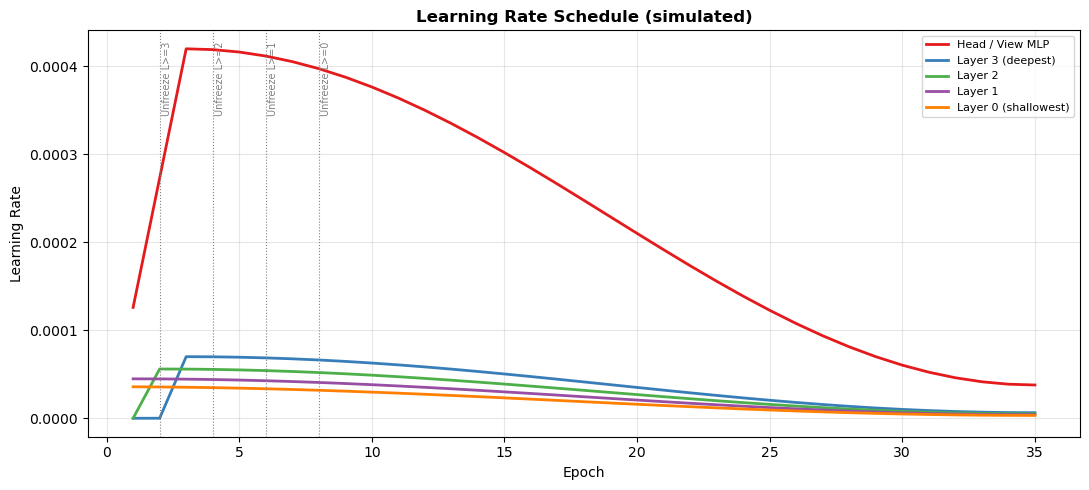

plot_lr_schedule() defined and executed.


In [23]:
def plot_lr_schedule(n_epochs=NUM_EPOCHS):
    """Simulate and plot the LR trajectory for head and each backbone layer."""
    layer_names = [f'backbone.layer{i}' for i in range(4)]
    layers_info = [
        {'name': 'Head / View MLP', 'base_lr': BASE_LR * HEAD_LR_MULTIPLIER, 'layer_idx': -1, 'unfreeze_epoch': 1},
        {'name': 'Layer 3 (deepest)', 'base_lr': BASE_LR * (LR_LAYER_DECAY**0), 'layer_idx': 3, 'unfreeze_epoch': UNFREEZE_SCHEDULE.get(2, 2)},
        {'name': 'Layer 2', 'base_lr': BASE_LR * (LR_LAYER_DECAY**1), 'layer_idx': 2, 'unfreeze_epoch': UNFREEZE_SCHEDULE.get(4, 4)},
        {'name': 'Layer 1', 'base_lr': BASE_LR * (LR_LAYER_DECAY**2), 'layer_idx': 1, 'unfreeze_epoch': UNFREEZE_SCHEDULE.get(6, 6)},
        {'name': 'Layer 0 (shallowest)', 'base_lr': BASE_LR * (LR_LAYER_DECAY**3), 'layer_idx': 0, 'unfreeze_epoch': UNFREEZE_SCHEDULE.get(8, 8)},
    ]

    fig, ax = plt.subplots(figsize=(11, 5))
    epochs  = list(range(1, n_epochs + 1))
    colors  = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

    for info, col in zip(layers_info, colors):
        lrs = []
        for ep in epochs:
            if ep < info['unfreeze_epoch']:
                lrs.append(0)
                continue
            if ep <= WARMUP_EPOCHS and info['layer_idx'] < 0:
                t = (ep - 1) / max(WARMUP_EPOCHS - 1, 1)
                lr = info['base_lr'] * (WARMUP_START_FACTOR + t * (WARMUP_END_FACTOR - WARMUP_START_FACTOR))
            else:
                ue        = info['unfreeze_epoch'] if info['layer_idx'] >= 0 else WARMUP_EPOCHS
                effective = max(ep - ue, 0)
                T_max     = max(n_epochs - ue, 1)
                cos       = 0.5 * (1 + math.cos(math.pi * effective / T_max))
                eta_min   = info['base_lr'] * ETA_MIN_RATIO
                lr        = eta_min + (info['base_lr'] - eta_min) * cos
            lrs.append(lr)
        ax.plot(epochs, lrs, color=col, lw=2, label=info['name'])

    for ep, lidx in UNFREEZE_SCHEDULE.items():
        ax.axvline(ep, color='grey', ls=':', lw=0.8)
        ax.text(ep + 0.1, ax.get_ylim()[1] * 0.97,
                f'Unfreeze L>={lidx}', fontsize=7, color='grey', rotation=90, va='top')

    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule (simulated)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_lr_schedule()
print('plot_lr_schedule() defined and executed.')

### 8.7 Probability Calibration Curves

A well-calibrated model's predicted probability should equal the empirical positive rate.
Departures from the diagonal indicate over- or under-confidence.

In [24]:
def plot_calibration(probs_arr, labels_arr, results, n_bins=10):
    classes  = [c for c in ALL_CLASSES if c in results and c != 'No Finding']
    ncols    = 4
    nrows    = math.ceil(len(classes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    axes_flat  = axes.flatten()

    for i, cls in enumerate(classes):
        c      = ALL_CLASSES.index(cls)
        p      = probs_arr[:, c]
        y      = labels_arr[:, c]
        bins   = np.linspace(0, 1, n_bins + 1)
        bin_means, bin_fracs = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (p >= lo) & (p < hi)
            if mask.sum() > 0:
                bin_means.append(p[mask].mean())
                bin_fracs.append(y[mask].mean())
        ax = axes_flat[i]
        ax.plot(bin_means, bin_fracs, 'b-o', ms=4, label='Model')
        ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Perfect')
        ax.set_title(cls, fontsize=9, fontweight='bold')
        ax.set_xlabel('Mean Predicted Prob', fontsize=7)
        ax.set_ylabel('Fraction Positive', fontsize=7)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)

    plt.suptitle('Calibration Curves', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot_calibration(probs_arr, labels_arr, results)
print('plot_calibration() defined.')

plot_calibration() defined.


### 8.8 Learned View Conditioning Inspection

The FiLM values produced by the view MLP for PA vs AP can be inspected
to confirm the model has learned meaningful differences between the two views.

In [26]:
def inspect_view_conditioning(model, device):
    model.eval()
    scale = torch.sigmoid(model.view_scale).item() * 2.0
    print(f'Learned view_scale: {scale:.4f}')

    with torch.no_grad():
        for view_name, vid in [('PA (0)', 0), ('AP (1)', 1)]:
            v_t = torch.tensor([vid], dtype=torch.long).to(device)
            out = model.view_mlp(model.view_embed(v_t))[0]   # (C*2,)
            C   = out.shape[0] // 2
            gamma, beta = out[:C].cpu().numpy(), out[C:].cpu().numpy()
            gamma = np.tanh(gamma)
            print(f'  {view_name}  gamma mean={gamma.mean():.4f} std={gamma.std():.4f} '
                  f'  beta mean={beta.mean():.4f} std={beta.std():.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    with torch.no_grad():
        gammas, betas = [], []
        for vid in [0, 1]:
            v_t = torch.tensor([vid], dtype=torch.long).to(device)
            out = model.view_mlp(model.view_embed(v_t))[0]
            C   = out.shape[0] // 2
            gammas.append(np.tanh(out[:C].cpu().numpy()))
            betas.append(out[C:].cpu().numpy())
    for ax, vals, title in [
        (axes[0], [g - gammas[1] for g in gammas], 'γ: PA - AP difference'),
        (axes[1], [b - betas[1]  for b in betas],  'β: PA - AP difference')
    ]:
        diff = gammas[0] - gammas[1] if 'gamma' in title.lower() else betas[0] - betas[1]
        ax.hist(diff, bins=40, color='steelblue', edgecolor='white', lw=0.3)
        ax.axvline(0, color='red', ls='--', lw=1)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Difference'); ax.set_ylabel('Count')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('view_conditioning.png', dpi=150, bbox_inches='tight')
    plt.show()

# inspect_view_conditioning(raw_model, device)
print('inspect_view_conditioning() defined.')

NameError: name 'raw_model' is not defined

### Known Limitations
- **Hernia** has < 250 training examples, making its AUC unreliable.
- No external test set evaluation; reported AUC is on the held-out validation split.
- Labels in CXR8 are mined from radiology reports via NLP and contain noise (~10–20%).
